In [ ]:
import os

cwd = os.getcwd()                           # .../Lab/Code/Lab_8
lab_root = os.path.dirname(os.path.dirname(cwd))    # go back twice → .../Lab
DS_folder_directory = os.path.join(lab_root, "Dataset", "LAB8", "T-newsgroups")     # go forward twice

DS = os.listdir(DS_folder_directory)
corpus = []
for doc in DS:
    # before opening the file build the correct file path otherwise it tries to open '1069' from the current directory and of course it can't find anything
    full_path = os.path.join(DS_folder_directory, doc)

    with open(file=full_path, mode='r', encoding='latin1') as f:
        text = f.read()         # take whole content of the file
        corpus.append(text)      # throw it in a list

print(corpus[:2])
print(len(corpus))

# 2. Focus now on the data preparation step = turn strings into number so that we can perform clustering.
Textual data needs to be processed to obtain a numerical representation of each document.  
This is typically achieved by applying a weighting schema.  
Choose one of the weighting schemas that you know and transform each news into a numerical representation.
> The Python implementation of a simple TFIDF weighting schema is provided in section 3.3.1, you can use it as starting point.

---

#### 3.3.1
```python
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords as sw


class LemmaTokenizer(object):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()

    def __call__(self, document):
        lemmas = []
        for t in word_tokenize(document):
            t = t.strip()
            lemma = self.lemmatizer.lemmatize(t)
            lemmas.append(lemma)
        return lemmas


lemmaTokenizer = LemmaTokenizer()

vectorizer = TfidfVectorizer(
    tokenizer=lemmaTokenizer,
    stop_words=sw.words('english')
)

# corpus = list of documents as strings
tfidf_X = vectorizer.fit_transform(corpus)
```

# What's going on?
> That whole code block is doing one thing: Turn a list of raw text documents (corpus = [...]) into a TF-IDF matrix (tfidf_X) that you can feed to clustering.

Pipeline:
1.	You define a custom tokenizer (LemmaTokenizer) that:  
- splits text into tokens (words),
- normalizes them (lemmatization).

2.	You build a TfidfVectorizer that:  
- uses that tokenizer,
- removes English stopwords.

3.	You call fit_transform(corpus) and get:  
- a big matrix tfidf_X with shape (n_docs, n_terms).

Everything else is just plumbing to do these three steps.

#### 2. Why do we need tokenizer, lemmatizer, stopwords?
You could do:
```python
vectorizer = TfidfVectorizer()
tfidf_X = vectorizer.fit_transform(corpus)
```
and it would work.

**But** it would be “dumb” text processing:
- punctuation handling is generic,
- no lemmatization → “cars” and “car” counted as different words,
- no control over tokenization,
- default stopwords removal (or none, depending on params).

The lab wants you to think about preprocessing quality, so they propose:
- Custom tokenizer: so you decide exactly how to split / normalize words.
- Lemmatization (WordNetLemmatizer): so variants collapse to one base form:
	- “cars”, “car’s” → “car”
	- “running”, “ran”, “runs” → “run”
- Stopwords (sw.words('english')): remove ultra-common garbage like “the”, “of”, “and”, which just add noise.

> So: **TfidfVectorizer** = “TF-IDF engine”,  
> **LemmaTokenizer + stop_words** = “how to clean text before TF-IDF”.  

#### 3. What the hell is __call__?
In Python, an object is callable if it has a __call__ method.

- example:
```python
class MyThing:
    def __call__(self, x):
        return x * 2

obj = MyThing()
print(obj(10))   # this calls obj.__call__(10) -> 20
```
So obj(...) is just syntactic sugar for obj.__call__(...)  

TfidfVectorizer expects tokenizer to be a callable:
- could be a normal function like this:
```python
def my_tokenizer(doc):
    return doc.split()
vectorizer = TfidfVectorizer(tokenizer=my_tokenizer)
```

- or an object with __call__, like your LemmaTokenizer.

SO just to get the idea:
```python
lemmaTokenizer = LemmaTokenizer()
tokens = lemmaTokenizer("This is a test")
```
> This actually calls LemmaTokenizer.__call__(lemmaTokenizer, "This is a test") under the hood.

#### 4. Line-by-line explanation of the code
```python
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords as sw
```
- TfidfVectorizer
    – scikit-learn class that:
	    - tokenizes documents,
        - builds vocabulary,
        - computes TF-IDF,
        - returns a sparse matrix.

- word_tokenize
    – NLTK function that splits a string into tokens (words, punctuation).

- WordNetLemmatizer
    – NLTK lemmatizer: turns "cars" → "car", "running" → "running" or "run"

- stopwords as sw
    – just alias: sw.words('english') will give you a list of English stopwords.


```python
class LemmaTokenizer(object):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
```
- self.lemmatizer = WordNetLemmatizer()
    – create one lemmatizer and store it in the object so you can reuse it.

```python
    def __call__(self, document):
        lemmas = []
        for t in word_tokenize(document):
            t = t.strip()
            lemma = self.lemmatizer.lemmatize(t)
            lemmas.append(lemma)
        return lemmas
```
- def __call__(self, document):
    – makes the object callable like a function: lemmaTokenizer(document).

- lemmas = []
    – list to collect processed tokens.

- for t in word_tokenize(document):
    – split the raw string document into tokens t.

- t = t.strip()
    – remove spaces around the token (e.g., " car " → "car").

- lemma = self.lemmatizer.lemmatize(t)
    – convert token to its base form.

- lemmas.append(lemma)
    – store the processed token.

- return lemmas
    – final result: list of normalized tokens from that document.


**EXAMPLE:**  
```python
lemmaTokenizer = LemmaTokenizer()
lemmaTokenizer("Cars are running")  # → ["Car", "are", "running"] (roughly)
```

I create the LemmaTokenizer object and I pass the object something, then the function __call__ will automatically be applied on whatever we passed the LemmaTokenizer object --> in this example we will apply the __call__ function to "Cars are running".  

```python
lemmaTokenizer = LemmaTokenizer()
```
- create a LemmaTokenizer object that we'll pass to the TfidfVectorizer --> **TfidfVectorizer(tokenizer=...)**

**We can finally build the vectorizer**:
```python
vectorizer = TfidfVectorizer(
    tokenizer=lemmaTokenizer,
    stop_words=sw.words('english')
)
```

> - tokenizer=lemmaTokenizer
>     – **whenever TfidfVectorizer needs to process a document, it will call**:
```python
tokens = lemmaTokenizer(document)
```
>   - which **runs your __call__** and returns the lemmatized tokens.

```python
stop_words=sw.words('english')
```
– sw.words('english') is a list like ["the", "and", "is", ...].
– TfidfVectorizer will drop those tokens from the text.

So the pipeline for one document is:
> 1.	Call lemmaTokenizer(doc):  
    - tokenize → lemmatize → return tokens
> 2.	Drop tokens that are in the stopword list 
> 3.	Count remaining tokens  
> 4.	Compute TF-IDF across the corpus  

**Now that we created the vectorizer which is a TfidfVectorizer object, we can finally use it to transform the corpus:**
```python
# corpus = list of documents as strings
tfidf_X = vectorizer.fit_transform(corpus)
```

where corpus must be::
```python
corpus = [
    "raw text of document 1",
    "raw text of document 2",
    ...
]
```

fit_transform (generic):
1.	fit:  
- look at all docs,
- build vocabulary (which words exist),
- compute IDF for each word.
2.	transform:  
- for each document: compute TF-IDF of each word.

---

This preprocessing phase is likely to have the greatest impact on the quality of your results. Pay enough attention to it. You could try to answer the following questions:
- Which weighing schema have you used?
- Have you tried to remove stopwords?
- More generally, have you ignored words with a document frequency lower than or higher than a given threshold?
- Have you applied any dimensionality reduction strategy? This is not mandatory, but in some cases it can improve your results. You can find more details in Appendix 3.5.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords as sw

In [ ]:
# no way even after the pip install I still need to download some stuff INSIDE the python script to use it >:(
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')   # <- new, required
nltk.download('wordnet')

In [ ]:
class LemmaTokenizer(object):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()       # placed here and not inside the __call__ because the call is used thousands of times and you would create a WordNetLemmatizer object each time --> expensive

    def __call__(self, document):
        # lemmatizer = WordNetLemmatizer()          --> you could, but more expensive
        lemmas = []
        for t in word_tokenize(document):           # divides the document in tokens == single words
            t = t.strip()
            lemma = self.lemmatizer.lemmatize(t)    # 'running', 'runs', 'ran' --> lemma = 'run'
            lemmas.append(lemma)
        return lemmas

lemmaTokenizer = LemmaTokenizer()

vectorizer = TfidfVectorizer(
    tokenizer=lemmaTokenizer,
    stop_words=sw.words('english')
)

# corpus = list of documents as strings
tfidf_X = vectorizer.fit_transform(corpus)
print(tfidf_X)

In [ ]:
tfidf_X.shape

The output is like:
```text
Coords	Values
  (0, 38220)	0.023347559686131964
  (0, 11094)	0.04772901856532066
  (0, 28241)	0.08500107722463524
  (0, 14278)	0.016812897117440075
  (0, 11168)	0.01482194541780151
  (0, 17317)	0.06979305066720194
  (0, 11400)	0.0355357135692964
  (0, 38659)	0.06979305066720194
  (0, 11398)	0.18565901762183692
  (0, 27741)	0.1068499924082492
  (0, 41236)	0.06979305066720194
  (0, 540)	0.049754320855122165
  (0, 15832)	0.03860400857720436
  (0, 541)	0.0985523321601854
  (0, 54753)	0.01584634347556992
  (0, 54690)	0.018865237902956987
  (0, 33761)	0.08886377155452234
  (0, 46321)	0.05423641578621696
  (0, 46582)	0.04362956953490269
  (0, 22403)	0.0447080925830003
  (0, 30383)	0.04961116080366391
  (0, 1208)	0.22471335261832254
  ```
  
#### How do I read this??
tfidf_X.shape --> (4000, 55846)
- rows = documents --> 4000 documents
- columns = words --> 55846 different words

> “Document row, word column → TF-IDF weight value”  
Example:  
**(0, 38220)  0.023347559686131964**  

- 0 = row index → document 0 (your first news article)
- 38220 = column index → vocabulary term number 38 220
- 0.0233... = the TF-IDF weight of that term in that document

#### Hmmmmmm .... reminds me of OneHotEncoding
Conceptually it’s similar to One-Hot Encoding in this sense:
- One dimension (column) per word.
- Each document becomes a vector of length 55k+.

But the values are different:
- One-Hot: values are typically 0 or 1 (“word absent / present”).
- TF-IDF: values are weights, usually in [0, 1], reflecting
> “how important is this word in this doc given the whole corpus”.  

> So: same shape idea as one-hot, but richer values, not just binary.

---

- Which weighing schema have you used?  
TF-IDF, as the lab rat wanted.

- Have you tried to remove stopwords?  
yes, if I don't remove stopwords it just adds new columns because it considers stop words too, so I'll drop them.

- More generally, have you ignored words with a **document frequency** lower than or higher than a given threshold?  
Yes, the rat want us to use stuff he didn't mention and expects us to just know it:

In [ ]:
class LemmaTokenizer(object):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()       # placed here and not inside the __call__ because the call is used thousands of times and you would create a WordNetLemmatizer object each time --> expensive

    def __call__(self, document):
        # lemmatizer = WordNetLemmatizer()          --> you could, but more expensive
        lemmas = []
        for t in word_tokenize(document):
            t = t.strip()
            lemma = self.lemmatizer.lemmatize(t)
            lemmas.append(lemma)
        return lemmas

lemmaTokenizer = LemmaTokenizer()

vectorizer = TfidfVectorizer(
    tokenizer=lemmaTokenizer,
    stop_words=sw.words('english'),
    # ADD THIS
    min_df=5,       # ignore words that appear in < 5 documents
    max_df=0.7      # or ignore words that appear in > 70% of documents
)

tfidf_X = vectorizer.fit_transform(corpus)
print(tfidf_X)

Goddamn crazy dimensionality reduction!

> - Have you applied any dimensionality reduction strategy? This is not mandatory, but in some cases it can improve your results. You can find more details in Appendix 3.5.

#### Appendix
> “do you want to compress your 55k-dim TF-IDF vectors to, say, 50–200 dims before clustering, using PCA-like stuff (SVD)?”

With TF-IDF you now have:
- X.shape = (4000, 55846)
- 4000 documents
- 55k different words → 55k features

Problems with that:
- Many words are useless noise (rare typos, weird headers, etc.).
- Many words are redundant / correlated (“car” / “cars”, “drive” / “driving”).
- 55k-dimensional space is hard for clustering; distances get weird, it’s slow, noisy.

So they suggest:  
> “Maybe we can change coordinates and keep only a few important directions.”  
> **That’s dimensionality reduction**.  

> #### Geometric intuition (Gaussian picture)

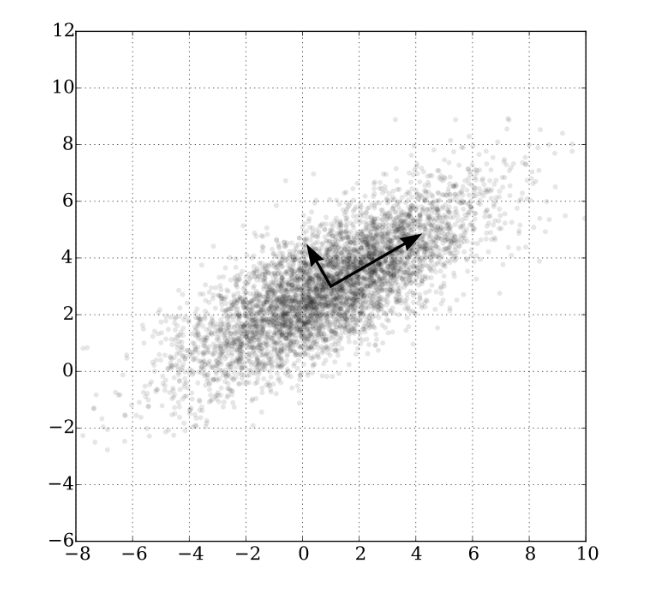  

Points distributed in a Gaussian cluster with mean (1,3) and standard deviation 3.  

They say:
- Imagine a 2D cloud of points that looks like a cigar:
- Big variance along some slanted direction
- Small variance across it
> - Our current axes are x and y (the boring horizontal/vertical).
> - But the “interesting” direction is the long axis of the cigar.

PCA idea:
- **Rotate the axes** so that:
> 	- PC1 (first principal component) = direction of largest variance (the long axis).
> 	- PC2 = second direction, orthogonal, with the next largest variance.  
	- In higher dimension, same idea: find orthogonal directions ranked by how much variance they explain.

> Then you can **keep only the first k components** (k < original dimension)

> #### Matrix view: X, P, Y
- Original data: X (e.g. shape (4000, 55846))
- We look for a matrix P (projection/change-of-basis).
- New data: **Y = X * P**

Where:
- Rows of Y = same documents
- Columns of Y = new features (principal components), e.g. 100 instead of 55k.

So:
- Before: each doc = 55k-dimensional TF-IDF vector.
- After PCA/SVD: each doc = 100-dimensional vector (but each dim is a mix of many words).

### SVD / TruncatedSVD, but before
### 1. PCA reminder (what it really does)  
Data matrix:
- $X \in \mathbb{R}^{n \times d}$
- n = number of samples
- d = number of features

For the example, we’ll use 3 points in 2D:

$X = \begin{bmatrix} 0 & 0 \\ 2 & 2 \\ 3 & 3 \end{bmatrix} \quad (n=3, d=2)$

They clearly lie roughly on the line “y = x”.

#### **Step 1 – Center the data**
Compute the mean of each feature (column):  
$\mu_j = \frac{1}{n} \sum_{i=1}^n X_{ij}$  

Build mean vector $\mu \in \mathbb{R}^d$, then subtract it:  
$ X_{\text{centered}} = X - \mathbf{1} \mu^\top $  

where $\mathbf{1}$ is an n-vector of ones.

**Example:**  
- Feature 1: (0 + 2 + 3) / 3 = 5/3 ≈ 1.67
- Feature 2: same → 5/3

$\mu = \begin{bmatrix} 5/3 & 5/3 \end{bmatrix}$

Subtract from each row:
$X_{\text{centered}} = \begin{bmatrix} 0 - 5/3 & 0 - 5/3 \\ 2 - 5/3 & 2 - 5/3 \\ 3 - 5/3 & 3 - 5/3 \end{bmatrix} = \begin{bmatrix} -5/3 & -5/3 \\ 1/3 & 1/3 \\ 4/3 & 4/3 \end{bmatrix}$

So now the cloud is centered around the origin.

⸻

#### **Step 2 – Covariance matrix**
$\Sigma = \frac{1}{n} X_{\text{centered}}^\top X_{\text{centered}} \quad \in \mathbb{R}^{d \times d}$

This tells you how features vary and co-vary.

First compute $X_{\text{centered}}^\top X_{\text{centered}}$

Each row is a vector $r_i = (x_i, y_i)$.
The outer product will have shape $r_i^\top r_i (2×2)$ --> as $X_{centered}$ is a 3x2, so $X_{\text{centered}}^\top$ is 2x3 * 3x2 = 2x2 and is:

$r_i^\top r_i = \begin{bmatrix} x_i^2 & x_i y_i \\ x_i y_i & y_i^2 \end{bmatrix}$

--> MEH, this is just what you get after doing riga-per-colonna product:  
$X_{\text{centered}} = \begin{bmatrix} -5/3 & -5/3 \\ 1/3 & 1/3 \\ 4/3 & 4/3 \end{bmatrix}$  

$X_{\text{centered}}^\top = \begin{bmatrix} -5/3 & 1/3 & 4/3 \\ -5/3 & 1/3 & 4/3 \end{bmatrix}$  
Entry $M_{11}$: (row 1 ⋅ col 1)  
Row 1 of $X^\top: \big[-5/3,\ 1/3,\ 4/3\big]$  
Column 1 of $X: \begin{bmatrix}-5/3 \\ 1/3 \\ 4/3 \end{bmatrix}$  

$ M_{11} = \left(-\frac{5}{3}\right)\left(-\frac{5}{3}\right) + \left(\frac{1}{3}\right)\left(\frac{1}{3}\right) + \left(\frac{4}{3}\right)\left(\frac{4}{3}\right) = \frac{25}{9} + \frac{1}{9} + \frac{16}{9} = \frac{25 + 1 + 16}{9} = \frac{42}{9} = \frac{14}{3}$

Divide by n = 3 --> $\frac{14}{9}$

Do this for each centered point:
- For (-5/3, -5/3):

$r^\top r = \begin{bmatrix} x_i^2 & x_i y_i \\ x_i y_i & y_i^2\end{bmatrix} = \begin{bmatrix} \left(-\frac{5}{3}\right)^2 & \left(-\frac{5}{3}\right)\left(-\frac{5}{3}\right) \\ \left(-\frac{5}{3}\right)\left(-\frac{5}{3}\right) & \left(-\frac{5}{3}\right)^2 \end{bmatrix}$

Now compute $\left(-\frac{5}{3}\right)^2$:
$\left(-\frac{5}{3}\right)^2 = (-5)^2 / 3^2 = 25/9$

So every entry becomes 25/9:
$r^\top r = \begin{bmatrix} 25/9 & 25/9 \\ 25/9 & 25/9 \end{bmatrix} = \frac{25}{9} \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}$

- For (1/3, 1/3):
$\frac{1}{9} \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}$

- For (4/3, 4/3):
$\frac{16}{9} \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}$

- Sum them:
$X_{\text{centered}}^\top X_{\text{centered}} = \left(\frac{25}{9} + \frac{1}{9} + \frac{16}{9}\right) \begin{bmatrix} 1 & 1 \\ 1 & 1 \end {bmatrix} = \frac{42}{9} \begin{bmatrix} 1 & 1 \\ 1 & 1\end{bmatrix} = \frac{14}{3} \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}$

- Now divide by n = 3 to get $\Sigma$:
$\Sigma = \frac{1}{3} X_{\text{centered}}^\top X_{\text{centered}} = \frac{1}{3} \cdot \frac{14}{3} \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix} = \frac{14}{9} \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}$

- So explicitly:
$\Sigma = \begin{bmatrix} 14/9 & 14/9 \\ 14/9 & 14/9 \end{bmatrix}$

⸻

> **What is on the diagonal? (14/9 and 14/9)**  
These are the variances of each feature:
- Top-left: variance of feature 1 (x)
- Bottom-right: variance of feature 2 (y)

> Variance = “on average, how far is this feature from its mean, squared?”

In our example (after centering), the x values are:
$x = \left[-\frac{5}{3},\; \frac{1}{3},\; \frac{4}{3}\right]$

Variance of x is basically:
$[\operatorname{Var}(x) = \text{average of } x^2 = \frac{1}{3}\left[\left(-\frac{5}{3}\right)^2 +\left(\frac{1}{3}\right)^2 +\left(\frac{4}{3}\right)^2\right]= \frac{14}{9}]$

Same for y, because in this toy example x and y are always equal.

So, 14/9 on the diagonal means: “**Each coordinate (x or y) wiggles around its mean with average squared distance 14/9.**”  
You can think: bigger diagonal → features change more; smaller diagonal → features almost constant.  

⸻

> **What is off the diagonal?** (14/9 and 14/9)  
These are the covariances:
- Top-right: covariance between x and y
- Bottom-left: same thing (matrix is symmetric)

Covariance answers:  
> “When x is above its mean, does y also tend to be above its mean? And by how much, on average?”

For our centered data, the pairs are:
$(x,y) = \left(-\frac{5}{3}, -\frac{5}{3}\right), \left(\frac{1}{3}, \frac{1}{3}\right), \left(\frac{4}{3}, \frac{4}{3}\right)$

Here:
- When x is negative, y is negative.
- When x is small positive, y is small positive.
- When x is larger positive, y is larger positive.

So x and y move together perfectly. That’s why:
- Cov(x, y) = 14/9 (same as variance)
- Positive and large: when x goes up, y goes up in sync.

If instead x and y were independent (no relationship), the off-diagonal would be close to 0.

⸻

#### Step 3 – Eigen-decomposition of $\Sigma$
We solve:
$\Sigma v_k = \lambda_k v_k$
- $v_k$ = eigenvector k (principal direction in feature space)
- $\lambda_k$ = eigenvalue (variance along that direction)

$\Sigma = \begin{bmatrix} a & a \\ a & a \end{bmatrix} \quad\text{with } a = 14/9$
We want its eigenvalues $\lambda$, i.e. solve:
$\det(\Sigma - \lambda I) = 0$

> 1. Build $\Sigma - \lambda I$  
$\Sigma - \lambda I =\begin{bmatrix} a & a \\ a & a \end{bmatrix} - \begin{bmatrix} \lambda & 0 \\ 0 & \lambda \end{bmatrix} = \begin{bmatrix} a - \lambda & a \\ a & a - \lambda \end{bmatrix}$

> 2. Compute the determinant
$ \det(\Sigma - \lambda I) = \begin{vmatrix} a - \lambda & a \\ a & a - \lambda \end{vmatrix} = (a - \lambda)(a - \lambda) - a \cdot a$

So:
$\det(\Sigma - \lambda I) = (a - \lambda)^2 - a^2$

Expand:
$(a - \lambda)^2 - a^2 = (a^2 - 2a\lambda + \lambda^2) - a^2 = -2a\lambda + \lambda^2 = \lambda^2 - 2a\lambda$

We set this equal to 0:
$\lambda^2 - 2a\lambda = 0$

Factor:
$\lambda(\lambda - 2a) = 0$

So the solutions are:
$\lambda_1 = 0, \quad \lambda_2 = 2a$


> 3. Plug in a = 14/9
$\lambda_1 = 0$
$\lambda_2 = 2a = 2 \cdot \frac{14}{9} = \frac{28}{9}$

**SO**
We have
$\Sigma = \begin{bmatrix} a & a \\ a & a \end{bmatrix}$
and we already found the eigenvalues:
$\lambda_1 = 2a, \quad \lambda_2 = 0$

Now we find the corresponding eigenvectors by solving:
$(\Sigma - \lambda I)\,v = 0$

for each $\lambda$.

⸻

> 1. Eigenvector for $\lambda_1 = 2a$

Compute $\Sigma - 2aI$:

$\Sigma - 2aI = \begin{bmatrix} a & a \\ a & a \end{bmatrix} - \begin{bmatrix} 2a & 0 \\ 0 & 2a \end{bmatrix} = \begin{bmatrix} a-2a & a \\ a & a-2a \end{bmatrix} = \begin{bmatrix} -a & a \\ a & -a \end{bmatrix}$

Let the eigenvector be $v = \begin{bmatrix} x \\ y \end{bmatrix}$.
We need:

$\begin{bmatrix} -a & a \\ a & -a \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$

This gives the system:
1.	$-a x + a y = 0$  
2.	$a x - a y = 0$  

Take the first equation:
$-a x + a y = 0 \quad \Rightarrow \quad a(y - x) = 0$

Assuming a $\neq$ 0:
$y - x = 0 \quad \Rightarrow \quad y = x$

So any vector of the form $\begin{bmatrix} x \\ x \end{bmatrix}$ is an eigenvector.
A simple choice: x=1 → $v_1$ = $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$.

That’s why for $\lambda_1 = 2a$, eigenvector is along [1,1].
> When you move along this eigenvector, you are moving along the line x = y: both coordinates change in the same way.

> - All your data points are roughly on the line x = y.
> - The vector [1,1] points exactly along that line.
> - If you move in that direction (add t·[1,1] = (t,t) to a point), x and y change together.
> - That’s the direction where the data “spreads out” the most → big variance → big eigenvalue.

So: “Direction along the diagonal where both coordinates increase together” = move along [1,1] → you go up-right on the x = y line.

⸻

> 2. Eigenvector for $\lambda_2$ = 0  

Now solve $(\Sigma - 0\cdot I)v = \Sigma v = 0$:

$ \begin{bmatrix} a & a \\ a & a \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix} $

This gives:  
1.	a x + a y = 0  
2.	a x + a y = 0  

From the first:
$a(x + y) = 0 \quad \Rightarrow \quad x + y = 0 \quad \Rightarrow \quad y = -x$

So any vector of the form $\begin{bmatrix} x \\ -x \end{bmatrix}$ is an eigenvector.
Take x = 1 → $v_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$.

That’s why for $\lambda_2 = 0$, eigenvector is along [1,-1].

Vector [1, -1] means “x goes up, y goes down by the same amount”.
- Start from (0,0):
	- +[1, -1] → (1, −1)
	- +[1, -1] → (2, −2)
	- +[1, -1] → (3, −3)

That’s the line y = −x, which is perpendicular to x = y.

> Why “no variance” along [1, -1]?  
Look again at the 3 points:  
- (−5/3, −5/3)
- (1/3, 1/3)
- (4/3, 4/3)

All of them satisfy x = y.

⸻

> Normalize them if you want unit length:

$v_1 = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 \\ 1 \end{bmatrix}, \quad v_2 = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 \\ -1 \end{bmatrix}$

Geometric meaning:
- Data lie roughly on a line at 45° (direction [1,1]).
→ big variance → big eigenvalue $\lambda_1$ = 28/9.

- The orthogonal direction [1,-1] has almost no spread → eigenvalue 0.

⸻

#### Step 4 – Pick the top K eigenvectors (principal components)

Build matrix $V_K \in \mathbb{R}^{d \times K}$ from the top K eigenvectors as columns:

$V_K = [v_1 \; v_2 \; \dots \; v_K]$

Often you choose $K \ll d$ to reduce dimensionality.

**Concrete example (d = 2, pick K = 1)**  
Here d = 2. Suppose we keep only the main direction (the one with largest variance):
$v_1 =\frac{1}{\sqrt{2}}\begin{bmatrix}1 \\1\end{bmatrix}$

Then
$V_1 =\begin{bmatrix}1/\sqrt{2} \\1/\sqrt{2}\end{bmatrix}$

> $V_1$ BECOMES THE NEW AXIS, no more x and y

Interpretation:
> “We only keep the direction along the line of the points. We throw away the perpendicular direction that has zero variance.”

⸻

#### Step 5 – Project data onto these components

$Y = X_{\text{centered}} V_K \quad \in \mathbb{R}^{n \times K}$
- Each row of Y is the coordinate of the original sample in the new space.
- If K = 1, each point becomes a single number (how far along the main direction it is).

**Concrete example (K = 1)**  
We use  
$Y = X_{\text{centered}} V_1$

Recall:  
$[X_{\text{centered}} = \begin{bmatrix} -\frac{5}{3} & -\frac{5}{3} \\ \frac{1}{3} & \frac{1}{3} \\ \frac{4}{3} & \frac{4}{3} \end{bmatrix}, \quad V_1 = \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix}]$

Compute each projected value $y^{(i)}$ as the dot product:
1.	First centered point $x^{(1)} = (-5/3, -5/3)$:  

$y^{(1)}= x^{(1)} \cdot v_1= \begin{bmatrix} -5/3 & -5/3 \end{bmatrix}\cdot\frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1 \end{bmatrix}= \frac{-10/3}{\sqrt{2}}\approx -2.36$

2.	Second centered point $x^{(2)} = (1/3, 1/3)$:  
$y^{(2)}= \begin{bmatrix} 1/3 & 1/3 \end{bmatrix}\cdot\frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1 \end{bmatrix}= \frac{2/3}{\sqrt{2}}\approx 0.47$

3.	Third centered point $x^{(3)} = (4/3, 4/3)$:  
$y^{(3)}= \begin{bmatrix} 4/3 & 4/3 \end{bmatrix}\cdot\frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1 \end{bmatrix}= \frac{8/3}{\sqrt{2}}\approx 1.89$

So
$Y =\begin{bmatrix}-2.36 \\0.47 \\1.89\end{bmatrix}\quad (\text{approximately})$


#### Geometric picture (now with real numbers)
Originally, the three points were:
- (0, 0)
- (2, 2)
- (3, 3)
They lie along the diagonal line y = x.

**PCA**:
- Finds that diagonal direction ($v_1 = \frac{1}{\sqrt{2}}(1,1)$) as the main axis.
- Projects each point onto that line:
	- One becomes a large negative value (far one way)
	- One near zero (middle)
	- One large positive (far the other way)

> We collapsed the 2D diagonal line into a 1D axis but kept the essential order and distances along that line. No important information lost, because everything was already living on (roughly) a 1D structure inside 2D.

# This is PCA
Now after this reminder we can go back to what we were saying.

> # SVD / TruncatedSVD

> #### 1. Quick PCA reminder (what it really does)
You have a data matrix:
- $X \in \mathbb{R}^{n \times d}$
- n = number of samples (docs)
- d = number of features (words, 55k in your case)

Standard PCA steps (the “classical” way):
1.	Center the data (subtract the mean of each column/feature).  
2.	Compute the covariance matrix  
$\Sigma = \frac{1}{n} X^\top X \quad \in \mathbb{R}^{d \times d}$

3.	Eigen-decompose the covariance  
$\Sigma v_k = \lambda_k v_k$
- $v_k$ = eigenvector k → direction in feature space (principal component)
- $\lambda_k$ = eigenvalue → variance along that direction

4.	Sort eigenvectors by eigenvalue (largest variance first) and keep only the first K of them.  

5.	Project data onto those eigenvectors  
$Y = X V_K \quad (\text{dim } n \times K)$
→ each sample now has K new features = coordinates along those principal directions.

> #### 2. Why we don’t explicitly compute the covariance for TF-IDF
If you tried to do “classical PCA” literally on your TF-IDF:
- X shape ≈ (4000, 55 846)
- Covariance $\Sigma = X^\top X, shape ≈ (55 846, 55 846)$

Problems:
1.	Size explosion  
2.	Eigen-decomposition of a huge dense matrix is expensive  
Conclusion: direct covariance + eigendecomposition is a terrible idea for large, sparse text data.

# what you need to know about the SVD for this lab
You have:  
- tfidf_X = 4000 × 55 846 sparse matrix --> (4000 docs, 55k different words/features)

You call:
```python
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(tfidf_X)
```

- Input: giant sparse TF-IDF matrix.
- Output: X_reduced = 4000 × 100 dense matrix.
- Each doc is now a 100-dimensional vector instead of 55k-dimensional.
- These 100 new features are “important directions” that summarize the TF-IDF information.
- Then you run clustering (k-means, etc.) on X_reduced instead of on tfidf_X.

> # 2. What SVD is, in stupidly plain terms
Take a small numeric example:  
X = [[3, 1],
     [0, 2]]

SVD says: you can write X as
> ##### **X = U * Σ * Vᵀ**

Where:
U ≈ [[ 0.96, -0.29],
     [ 0.29,  0.96]]

Σ ≈ [[3.26, 0   ],
     [0   , 1.84]]

Vᵀ ≈ [[ 0.88,  0.47],
      [-0.47,  0.88]]


- Vᵀ = “directions in feature space” (here we have 2 words/features, so 2 directions).
	- First row ≈ [0.88, 0.47] = first direction is “0.88·feature1 + 0.47·feature2”.
     - Second row ≈ [-0.47, 0.88] = second direction, perpendicular to the first.
     
- Σ = how MUCH each direction matters.
     - First singular value ≈ 3.26 (big) → a lot of variation in that direction.
     - Second singular value ≈ 1.84 (smaller) → less variation.

- U = how each row of X (each sample) is expressed in terms of those directions.

> If you multiply U * Σ * Vᵀ back, you get exactly X again (up to floating-point rounding).

> SVD = “Rotate into nice directions (Vᵀ), stretch by how important they are (Σ), then maybe rotate again (U).”

In [ ]:
# so all this pain in the ass to basically do this

svd = TruncatedSVD(n_components=1000, random_state=42)
X_reduced = svd.fit_transform(tfidf_X)

print(X_reduced)

# feed this to a clustering model

## It's pretty chaotic now though and this matrix seems meaningless ....
Start from before PCA/SVD:
- You had tfidf_X with shape (4000, 55846)
    - 4000 documents
    - 55 846 words/features

Each row is already: “This document, represented as a huge vector in a 55k-dimensional word space.”  

So doc 0 is:
$\text{doc}_0 = [w_1, w_2, \dots, w_{55846}]$

You don’t see all 55k numbers, but that’s what it is.

Geometric interpretation:
> - Each document = one point in a 55 846-dimensional space.
> - Coordinates = TF-IDF weights for each word.

So already the rule is: “One document → one vector → one point.”

#### 2. What PCA / TruncatedSVD did to that
> PCA/SVD says: “Hey, this 55k-dim space is insane. Let’s compress it to, say, 100 dimensions that preserve most of the structure.”

So you take tfidf_X (4000, 55846) and get: X_reduced.shape == (4000, 100)

- Still 4000 rows → still 4000 documents
- Now only 100 features → 100 “abstract directions” (principal components)
X_reduced[0] = [0.1075, 0.1411, -0.2344, ..., 0.0011] --> length 100

This means:
Doc 0 = 0.1075 * PC₁  
+ 0.1411 * PC₂  
+ (−0.2344) * PC₃  
+ …  
+ 0.0011 * PC₁₀₀  

> Where each PCₖ (principal component) is a direction in word space, i.e. a particular combination of words.  
So:  
- Before: doc = combo of words
- After PCA: doc = combo of components, each component = combo of words

You compressed meaning into fewer, more abstract axes.

####  Why one point per row in a 2D plot?
For each document i:
- x-coordinate = its value on component 1
- y-coordinate = its value on component 2

So:
- Doc 0 → point (X_reduced[0,0], X_reduced[0,1]) = (0.1075, 0.1411)
- Doc 1 → point (X_reduced[1,0], X_reduced[1,1]) = (0.6128, -0.0814)

> **Each row is still describing one document**, just in a **new coordinate system** (components instead of raw words). So you plot one point per doc, not per number.

# “I completely lost the connection to the original words”
**YES**
> That’s the price you pay for dimensionality reduction


---

---

# Let's clean this up

In [ ]:
cwd = os.getcwd()                           # .../Lab/Code/Lab_8
lab_root = os.path.dirname(os.path.dirname(cwd))    # go back twice → .../Lab
DS_folder_directory = os.path.join(lab_root, "Dataset", "LAB8", "T-newsgroups")     # go forward twice

DS = os.listdir(DS_folder_directory)
corpus = []
for doc in DS:
    # before opening the file build the correct file path otherwise it tries to open '1069' from the current directory and of course it can't find anything
    full_path = os.path.join(DS_folder_directory, doc)

    with open(file=full_path, mode='r', encoding='latin1') as f:
        text = f.read()         # take whole content of the file
        corpus.append(text)      # throw it in a list

In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')   # <- new, required
nltk.download('wordnet')

In [ ]:
class LemmaTokenizer(object):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()       # placed here and not inside the __call__ because the call is used thousands of times and you would create a WordNetLemmatizer object each time --> expensive

    def __call__(self, document):
        # lemmatizer = WordNetLemmatizer()          --> you could, but more expensive
        lemmas = []
        for t in word_tokenize(document):
            t = t.strip()
            lemma = self.lemmatizer.lemmatize(t)
            lemmas.append(lemma)
        return lemmas



lemmaTokenizer = LemmaTokenizer()

vectorizer = TfidfVectorizer(
    tokenizer=lemmaTokenizer,
    stop_words=sw.words('english'),
    min_df=5,       # ignore words that appear in < 5 documents
    max_df=0.7      # or ignore words that appear in > 70% of documents
)

tfidf_X = vectorizer.fit_transform(corpus)
print(tfidf_X)

In [ ]:
svd = TruncatedSVD(n_components=500, random_state=42)
X_reduced = svd.fit_transform(tfidf_X)

print(X_reduced.shape)
print(X_reduced)

---

#### Finally we can feed this to a clustering model
> 3. Once you have your vector representation, choose one clustering algorithm of those you know and apply it to your data.

In [ ]:
from sklearn.cluster import KMeans, DBSCAN

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --> before explore the data distribution <--

# [[ 0.10756406  0.14113562 -0.23444927 ...  0.01062739 -0.0020329
#    0.00107566]
#  [ 0.6127611  -0.08136232 -0.00872677 ...  0.00155861  0.00696839
#    0.01505078]

# Each row = 1 document.
# Each column = 1 principal component (PC), i.e. a latent direction / topic-ish axis.

x = X_reduced[:,0]                      # coordinate of every document along PC1
y = X_reduced[:,1]                      # coordinate of every document along PC2
plt.figure(figsize=(8,6))
sns.scatterplot(x=x, y=y)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Score among all documents of PC1 and PC2')
plt.show()

# meaning of the plot:
# Documents that appear close together in this plot:
	# use words in a similar way (in terms of those 2 components),
	# so they’re likely about related topics.

# Documents that are far apart:
	# have very different word usage patterns.

In [ ]:
plt.figure(figsize=(10,10))
subplot_idx=0
for idx in range(0,500,100):
    subplot_idx += 1
    plt.subplot(3,2,subplot_idx)
    sns.scatterplot(x=X_reduced[:, idx], y=X_reduced[:, idx+1])
    plt.xlabel(f'Principal Component {idx}')
    plt.ylabel(f'Principal Component {idx+1}')
    plt.title(f'Score among all documents of PC{idx} and PC{idx+1}')

plt.tight_layout()
plt.show()


In [ ]:
# try to plot random columns together
# pick random index number for columns
import random

plt.figure(figsize=(20,20))
plt_idx = 0
for idx in range(22):
    col_idx_x = random.randint(0, X_reduced.shape[1])
    col_idx_y = random.randint(0, X_reduced.shape[1])

    plt_idx += 1
    plt.subplot(6,4, plt_idx)
    sns.scatterplot(x=X_reduced[:, col_idx_x], y=X_reduced[:, col_idx_y])
    plt.xlabel(f'Principal Component {col_idx_x}')
    plt.ylabel(f'Principal Component {col_idx_y}')
    plt.title(f'Random scatter plot {idx}')

plt.tight_layout()
plt.show()



# what clustering technique should we use?
> I ran the random plot a few times and I would say that the most diffused points distribution's shape is one big blob, one big globular and very dense cirle-ish + some outliers and noise around it

I would try to use the **DBSCAN** and the **KMeans** clustering

---

#### KMeans
You have: X_reduced.shape = (4000, 500)

Interpretation:
- 4000 = documents
- 500 = latent components (principal components after TruncatedSVD)

So each row is:
$\text{doc}_i = (x_{i1}, x_{i2}, \dots, x_{i,500})$

You can think:
> “Doc i = some combination of 500 hidden ‘directions’ that roughly encode topic-ish stuff.”

You lost the direct “word = column” meaning, but you gained a compressed representation where similar docs are closer in this 500D space.

⸻

The algorithm doesn’t change at all:
1.	Start with K random centroids in 500D.  
2.	Assign each doc to closest centroid (Euclidean distance in 500D).  
3.	Recompute each centroid as the mean of its documents in 500D.  
4.	Repeat.  

Your brain can’t visualize 500D, but the math is the same  

⸻

Each doc row:  
doc i = (PC1_weight, PC2_weight, ..., PC500_weight) --> 500 numbers  

This row = one document.  
Those 500 numbers = compressed description of what’s in that doc (kind of like a 500-dim “topic fingerprint”).  

You don’t know exactly what each number means, but:  
- Two docs about space will have similar 500 numbers.
- Two docs about football will have similar 500 numbers (maybe different from the space ones).
- A space doc and a football doc will have very different 500 numbers.

So:  
> “Similar numbers → similar content.”  

> What does K-means do on that?
Forget 500 dimensions. Think:  
- Each document = a long vector of numbers = its “fingerprint”.
- K-means just says: “Let me group documents with similar fingerprints together.”

In [ ]:
# I have no clue of the amount of clusters I should use .... let's try like this
l_n_clusters = [5, 10, 20, 30]
for n_clusters in l_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit_predict(X_reduced)
    
    centroids = kmeans.cluster_centers_
    clusters = kmeans.labels_


# how do I visualize the results in a 500 dimensions plot? As you did before pick like PC0 and PC1

### how do I visualize the results in a 500 dimensions plot?
As you did before pick like PC0 and PC1

- Taking two of the 500 dimensions (say PC17 and PC92).
- Plotting documents in that 2D projection.
- Colouring them by cluster.
- Plotting centroids projected in that same 2D subspace.

Geometrically:  
- K-means works in full 500D.
- Your plot is a shadow of that 500D clustering onto a 2D plane.
- If the clustering is “nice”, you often see blobs in that 2D projection that roughly match the clusters.

You’re not seeing “everything”, but you’re seeing slices of what K-means is doing.

In [ ]:
l_n_clusters = [5, 10, 20, 30]
for n_clusters in l_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit_predict(X_reduced)
    
    centroids = kmeans.cluster_centers_
    clusters = kmeans.labels_

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=clusters, legend=False)     # plot the points of 2 random ass columns
    sns.scatterplot(x=centroids[:, 0], y=centroids[:, 1], s=80, marker='X')             # show the cluster of those points
    plt.title('Clustering')
    plt.show()
    

In [ ]:
# pretty awful, maybe I got unlucky though, try again with random columns

l_n_clusters = [5, 10, 20, 30]

plt.figure(figsize=(10,10))
subplot_idx = 0
for n_clusters in l_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit_predict(X_reduced)
    centroids = kmeans.cluster_centers_
    clusters = kmeans.labels_

    random_col_x = random.randint(a=0, b=X_reduced.shape[1]-1)
    random_col_y = random.randint(a=0, b=X_reduced.shape[1]-1)

    subplot_idx += 1
    plt.subplot(2,2, subplot_idx)
    sns.scatterplot(x=X_reduced[:,random_col_x],
                    y=X_reduced[:,random_col_y],
                    hue=clusters,
                    legend=False)
    
    sns.scatterplot(x=centroids[:, random_col_x],
                    y=centroids[:, random_col_y],
                    s=80,
                    marker='X')
    
    plt.title(f'clustering with {n_clusters} clusters')
    plt.xlabel(f"random column {random_col_x}")
    plt.ylabel(f"random column {random_col_y}")

plt.tight_layout()
plt.show()

# Jesus Christ this is hideous
> Why the 2D “shadows” look like garbage?

You’re doing this:
- Data: 500-dim points (each doc after SVD).
- K-means: finds clusters in those 500 dims.
- Plot: pick two random dimensions out of the 500 and look at them.

Big issue: **Random components ≈ random slice of a 500D cloud**  
- Most directions in high-D are “boring”: you just see one big blob.
- Even if clusters are somewhat separated in 500D, that separation may live in combinations of many components, not in a single PC or a random pair.

> **So a “big globular cloud + noise” in 2D does not prove that K-means is nonsense; it mostly proves your 2D projection is not informative.**


⸻

# Actually let's do things properly, let's run the 'elbow method' to figure out the K number of clusters
- run KMeans with different n_clusters K
- compute SSE = KMeans.inertia_ for each KMeans with different n_clusters K
- plot the SSE in function of K

In [ ]:
SSEs = []
l_n_clusters = [5, 10, 20, 30, 50, 100, 200, 500]
for n_clusters in l_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit_predict(X_reduced)
    SSE = kmeans.inertia_
    SSEs.append(SSE)

plt.figure(figsize=(8,6))
plt.plot(l_n_clusters, SSEs, marker = 'o')
plt.xlabel('number of clusters')
plt.ylabel('SSE')
plt.title('Elbow method to determine K')
plt.show()

> No strong “natural” K from SSE alone.  
- The curve never clearly “bends and then flattens”; it just gradually flattens.  

> Reasonable region for K (if you must pick something from this):
- The curve visibly slows down after something like K ≈ 20–50 and becomes linear-ish.

In [ ]:
# fix K = 50

plt.figure(figsize=(15,15))
subplot_idx = 0

for _ in range(10):
    kmeans = KMeans(n_clusters=50, random_state=42)
    kmeans.fit_predict(X_reduced)
    centroids = kmeans.cluster_centers_
    clusters = kmeans.labels_

    random_col_x = random.randint(a=0, b=X_reduced.shape[1]-1)
    random_col_y = random.randint(a=0, b=X_reduced.shape[1]-1)

    subplot_idx += 1
    plt.subplot(4,3, subplot_idx)
    sns.scatterplot(x=X_reduced[:,random_col_x],
                    y=X_reduced[:,random_col_y],
                    hue=clusters,
                    legend=False)
    
    sns.scatterplot(x=centroids[:, random_col_x],
                    y=centroids[:, random_col_y],
                    s=80,
                    marker='X')
    
    plt.title(f'clustering with 50 clusters, plot {_}')
    plt.xlabel(f"random column {random_col_x}")
    plt.ylabel(f"random column {random_col_y}")

plt.tight_layout()
plt.show()

Take this for example:

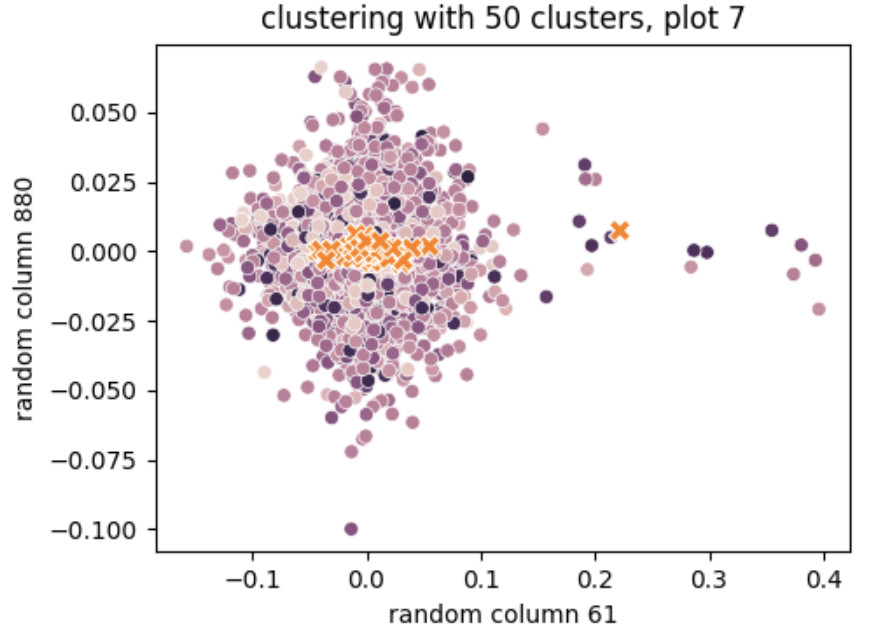

- On the y I have the column 880 on the x I have the column 61.  
- So from what I understood on the y axis I have the combination of WORDS (one topic) corresponding to the column 880, for example volleyball, jump, wall, save, ecc.
- On the x axis I have the combination of WORDS (one topic) corresponding to the column 61, for example constructions site, wall, drywall, nails, ecc.

> What do these points in the plot represent?  

Each point = one document.
- Its x-coordinate = how strongly that document is related on component 61 (volleyball).
- Its y-coordinate = how strongly that document is related on component 880 (construction).

So, a dot at (0.05, 0.02) means:  
> “This document has score 0.05 on the ‘construction-ish’ component and 0.02 on the ‘volleyball-ish’ component.”  

> That’s all the plot is: **every doc projected onto those two “topic directions” and colored by its K-means cluster**.  

---

# Let's try DBSCAN, here's some directions
```python
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=...,          # neighborhood radius
    min_samples=...,  # minPts (minimum neighbors to be a core point)
    metric="euclidean"  # or "cosine", etc.
)

labels = dbscan.fit_predict(X)   # X = your data matrix (n_samples, n_features)
```
- labels: length = number of samples.
- labels[i] = -1 → point i is noise
- labels[i] = 0, 1, 2, ... → cluster IDs
- There are no centroids (DBSCAN is not center-based).

```python
cluster_ids = np.unique(labels)
cluster_ids = cluster_ids[cluster_ids != -1]  # drop noise
n_clusters = len(cluster_ids)
```

> “How close do points have to be to count as neighbors?”  
**Tune it via k-distance plot**:
1.	For each point, compute distance to its k-th nearest neighbor --> **k = min_samples** or min_samples-1 --> **guess** the min_samples :)
2.	Sort those distances.  
3.	Look for an “elbow” / sharp change → that’s a candidate eps.  

### > **DBSCAN SUCKS WITH HIGH DIMENSIONALITY --> DROP DIMENSIONS TO 20!!!**

In [ ]:
svd = TruncatedSVD(n_components=20, random_state=42)
X_small =svd.fit_transform(X_reduced)

X_small.shape

In [ ]:
dbscan = DBSCAN(eps = '???',
                min_samples= '???',
                metric='euclidean')

labels = dbscan.fit_predict(X_reduced)

### To understand eps let's try min_samples = 5, from each point plot the distance between from the point to the 5th neighbour:
- get distance (euclidean) matrix from each point to each point,
- get 5th element, the distance from that point to the 5th neighbour,
- sort these 5th neighbour distances,
- plot these distances

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np


plt.figure(figsize=(15, 10))
subplot_idx = 0

# 1) choose a few min_samples
min_samples = [3, 5, 10, 20]

for min_sample in min_samples:
    
    # 2) fit k-NN on your data --> when you ask me for neighbors (.fit), I must return the 5 closest points for each sample
    nn = NearestNeighbors(n_neighbors=min_sample)

    nn.fit(X_reduced)

    # 3) get distances to the k nearest neighbours for each point
    distances, indices = nn.kneighbors(X_reduced)
    # distances has shape (n_points, min_samples) --> [0, 500, 1000] = distance from point 0 to its 1st neighbour (itself) is 0, distance from point 0 to its 2nd neighbour is 500, distance from point 0 to its 3rd neighbour is 1000
    # indices has shape (n_points, min_samples) --> [0, 2, 1] = For point 0, the 3 nearest neighbours are neighbour 1: point 0 (itself), neighbour 2: point 2, neighbour 3: point 1

    # distances =
    # [[0.0,   0.10, 0.12],
    #  [0.0,   0.08, 0.15],
    #  [0.0,   0.07, 0.20],
    #  [0.0,   0.05, 0.18]]

    # distance to the k=3 neigbour == all rows and only the third column == distances[:, k-1] which is the last column so distances[:, -1]
    k_distances = distances[:, -1]

    # 4) sort them
    k_distances_sorted = np.sort(k_distances)

    # 5) plot
    subplot_idx += 1
    plt.subplot(2,2,subplot_idx)
    plt.plot(k_distances_sorted)
    plt.ylabel(f"distance to {min_sample}-th nearest neighbour")
    plt.xlabel("points (sorted)")
    plt.title(f"{min_sample}-NN distance plot")
    plt.grid(True)

plt.tight_layout()
plt.show()


In general:
- Left part (low distances) → points sitting in dense regions (lots of neighbours close by).
- Right part (larger distances) → points in sparser regions / potential noise.

If the data has nice DBSCAN-friendly structure, the curve looks like:  
- Flat-ish for a long while (many dense points),
- Then a clear “elbow” where it suddenly bends upward → start of noise region.
- You then pick ε (eps) roughly at that bend.

> ### LOOK FOR AN ELBOW --> Choose eps near the start of the steep rise of that curve --> k = 10 and epsilon = 0.82

In [ ]:
eps = 0.82
min_samples= 10
dbscan = DBSCAN(eps = eps,
                min_samples= min_samples,
                metric='euclidean')

labels = dbscan.fit_predict(X_reduced)
# len(labels) == number of docs (4000)

# unique_clusters, points_per_cluster = np.unique(labels, return_counts=True)
# print(unique_clusters)
# print(points_per_cluster)

# choose two components to visualize
pcx, pcy = 0, 1   # or random ints in [0, X_reduced.shape[1)-1]

mask_core = labels != -1                        # [True, True, False, ...] boolean mask
cluster_documents = X_reduced[mask_core, :]     # documents assigned to some cluster

mask_noise = labels == -1                       # noise docs
noise_documents = X_reduced[mask_noise, :]


plt.figure(figsize=(20,15))
subplot_idx = 0
for _ in range(20):
    random_col_x = random.randint(a = 0, b = X_reduced.shape[1])
    random_col_y = random.randint(a = 0, b = X_reduced.shape[1])
    
    subplot_idx += 1
    plt.subplot(4,5,subplot_idx)
    sns.scatterplot(
        x=cluster_documents[:, random_col_x],
        y=cluster_documents[:, random_col_y],
        hue=labels[mask_core],
        palette="tab10",
        legend=False,
        s=20,
    )

    # noise points in gray
    plt.scatter(
        noise_documents[:, random_col_x],
        noise_documents[:, random_col_y],
        s=10,
        c="lightgray",
        label="noise",
    )

    plt.xlabel(f"random col {random_col_x}")
    plt.ylabel(f"random col {random_col_y}")
    plt.title(f"DBSCAN: eps={eps}, min_samples={min_samples}")

plt.tight_layout()
plt.show()

In [ ]:
# check if you're tweaking
unique, counts = np.unique(labels, return_counts=True)
for idx in range(len(unique)):
    print(f"Inside the cluster {unique[idx]} there are {counts[idx]} points")

# It's all gray = all noise
> Bro, in 500D TF-IDF space I have no idea where dense clusters are.

FUUUUUUUUCCCKKKKK

> #### OPS I forgot that I should have used X_small because DBSCAN struggles a lot with high dimensionality :)

In [ ]:
eps = 0.82
min_samples= 10
dbscan = DBSCAN(eps = eps,
                min_samples= min_samples,
                metric='euclidean')

labels = dbscan.fit_predict(X_small)
# len(labels) == number of docs (4000)

# unique_clusters, points_per_cluster = np.unique(labels, return_counts=True)
# print(unique_clusters)
# print(points_per_cluster)

# choose two components to visualize

mask_core = labels != -1                        # [True, True, False, ...] boolean mask
cluster_documents = X_small[mask_core, :]     # documents assigned to some cluster

mask_noise = labels == -1                       # noise docs
noise_documents = X_small[mask_noise, :]


plt.figure(figsize=(20,15))
subplot_idx = 0
for _ in range(20):
    random_col_x = random.randint(a = 0, b = X_small.shape[1]-1)
    random_col_y = random.randint(a = 0, b = X_small.shape[1]-1)
    
    subplot_idx += 1
    plt.subplot(4,5,subplot_idx)
    sns.scatterplot(
        x=cluster_documents[:, random_col_x],
        y=cluster_documents[:, random_col_y],
        hue=labels[mask_core],
        palette="tab10",
        legend=False,
        s=20,
    )

    # noise points in gray
    plt.scatter(
        noise_documents[:, random_col_x],
        noise_documents[:, random_col_y],
        s=10,
        c="lightgray",
        label="noise",
    )

    plt.xlabel(f"random col {random_col_x}")
    plt.ylabel(f"random col {random_col_y}")
    plt.title(f"DBSCAN: eps={eps}, min_samples={min_samples}")

plt.tight_layout()
plt.show()

In [ ]:
unique, counts = np.unique(labels, return_counts=True)
for idx in range(len(unique)):
    print(f"Inside the cluster {unique[idx]} there are {counts[idx]} points")

#### FUUUCCCCKKK AGAAAIINNNNNNN >:(
**All same colour = only one big cluster**:  
Before, with 500D:
- Distances were very large and similar → hard to form dense regions → almost all noise.

Now with 20D:
- Distances shrank / structure changed.
- Keeping eps=0.8 and min_samples=10 may make neighborhoods “too easy” to reach:
- many points within radius 0.8
- density chain effect → DBSCAN connects almost everything into a single cluster.


> AAAAAHHHHH, makes sense, redo the elbow thinghy.

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np


plt.figure(figsize=(15, 10))
subplot_idx = 0

# 1) choose a few min_samples
min_samples = [3, 5, 10, 20]

for min_sample in min_samples:
    
    # 2) fit k-NN on your data --> when you ask me for neighbors (.fit), I must return the 5 closest points for each sample
    nn = NearestNeighbors(n_neighbors=min_sample)

    nn.fit(X_small)

    # 3) get distances to the k nearest neighbours for each point
    distances, indices = nn.kneighbors(X_small)
    # distances has shape (n_points, min_samples) --> [0, 500, 1000] = distance from point 0 to its 1st neighbour (itself) is 0, distance from point 0 to its 2nd neighbour is 500, distance from point 0 to its 3rd neighbour is 1000
    # indices has shape (n_points, min_samples) --> [0, 2, 1] = For point 0, the 3 nearest neighbours are neighbour 1: point 0 (itself), neighbour 2: point 2, neighbour 3: point 1

    # distances =
    # [[0.0,   0.10, 0.12],
    #  [0.0,   0.08, 0.15],
    #  [0.0,   0.07, 0.20],
    #  [0.0,   0.05, 0.18]]

    # distance to the k=3 neigbour == all rows and only the third column == distances[:, k-1] which is the last column so distances[:, -1]
    k_distances = distances[:, -1]

    # 4) sort them
    k_distances_sorted = np.sort(k_distances)

    # 5) plot
    subplot_idx += 1
    plt.subplot(2,2,subplot_idx)
    plt.plot(k_distances_sorted)
    plt.ylabel(f"distance to {min_sample}-th nearest neighbour")
    plt.xlabel("points (sorted)")
    plt.title(f"{min_sample}-NN distance plot")
    plt.grid(True)

plt.tight_layout()
plt.show()

# Choose eps near the start of the steep rise of that curve.

> I'll keep K = 10 but I'll use eps = 0.2 / 0.25

In [ ]:
eps = 0.2
min_samples= 10
dbscan = DBSCAN(eps = eps,
                min_samples= min_samples,
                metric='euclidean')

labels = dbscan.fit_predict(X_small)
# len(labels) == number of docs (4000)

# unique_clusters, points_per_cluster = np.unique(labels, return_counts=True)
# print(unique_clusters)
# print(points_per_cluster)

# choose two components to visualize

mask_core = labels != -1                        # [True, True, False, ...] boolean mask
cluster_documents = X_small[mask_core, :]     # documents assigned to some cluster

mask_noise = labels == -1                       # noise docs
noise_documents = X_small[mask_noise, :]


plt.figure(figsize=(20,15))
subplot_idx = 0
for _ in range(20):
    random_col_x = random.randint(a = 0, b = X_small.shape[1]-1)
    random_col_y = random.randint(a = 0, b = X_small.shape[1]-1)
    
    subplot_idx += 1
    plt.subplot(4,5,subplot_idx)
    sns.scatterplot(
        x=cluster_documents[:, random_col_x],
        y=cluster_documents[:, random_col_y],
        hue=labels[mask_core],
        palette="tab10",
        legend=False,
        s=20,
    )

    # noise points in gray
    plt.scatter(
        noise_documents[:, random_col_x],
        noise_documents[:, random_col_y],
        s=10,
        c="lightgray",
        label="noise",
    )

    plt.xlabel(f"random col {random_col_x}")
    plt.ylabel(f"random col {random_col_y}")
    plt.title(f"DBSCAN: eps={eps}, min_samples={min_samples}")

plt.tight_layout()
plt.show()

In [ ]:
unique, counts = np.unique(labels, return_counts=True)
for idx in range(len(unique)):
    print(f"Inside the cluster {unique[idx]} there are {counts[idx]} points")

# BOH, we can't evaluate a 500D or a 20D plot visually because we are plotting it in 2D and it might look wwrong in 2D but it actually right in 20D or 500D --> to evaluate use evaluation metrics!!!

In [ ]:
# I'll try to use the X_small for KMeans too!
plt.figure(figsize=(15,15))
subplot_idx = 0

for _ in range(10):
    kmeans = KMeans(n_clusters=50, random_state=42)
    kmeans.fit_predict(X_small)
    centroids = kmeans.cluster_centers_
    clusters = kmeans.labels_

    random_col_x = random.randint(a=0, b=X_small.shape[1]-1)
    random_col_y = random.randint(a=0, b=X_small.shape[1]-1)

    subplot_idx += 1
    plt.subplot(4,3, subplot_idx)
    sns.scatterplot(x=X_small[:,random_col_x],
                    y=X_small[:,random_col_y],
                    hue=clusters,
                    legend=False)
    
    sns.scatterplot(x=centroids[:, random_col_x],
                    y=centroids[:, random_col_y],
                    s=80,
                    marker='X')
    
    plt.title(f'clustering with 50 clusters, plot {_}')
    plt.xlabel(f"random column {random_col_x}")
    plt.ylabel(f"random column {random_col_y}")

plt.tight_layout()
plt.show()

---

#### 4. You can now evaluate the quality of the cluster partitioning you obtained. There exist many metrics based on distances between points (e.g., the Silhouette or the Sum of Squared Errors (SSE)) that you can explore. Choose one of those that you known and test your results on your computer.

In [ ]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=50, random_state=42)
kmeans.fit_predict(X_reduced)
clusters = kmeans.labels_
SSE = kmeans.inertia_

# silhouette score KMeans
s_score = silhouette_score(X=X_reduced, labels=clusters, random_state=42)
print(f"Silhouette score: {s_score}")
print(f"SSE (the lower the better): {SSE}")

In [ ]:
# try KMeans but with X_small
kmeans = KMeans(n_clusters=50, random_state=42)
kmeans.fit_predict(X_small)
clusters = kmeans.labels_
SSE = kmeans.inertia_

# silhouette score KMeans
s_score = silhouette_score(X=X_small, labels=clusters, random_state=42)
print(f"Silhouette score: {s_score}")
print(f"SSE (the lower the better): {SSE}")

In [ ]:
# same with DBSCAN
dbscan = DBSCAN(eps=0.82, min_samples=10, n_jobs=-1)
labels = dbscan.fit_predict(X_reduced)

# silhouette score DBSCAN
s_score = silhouette_score(X=X_reduced, labels=labels, random_state=42)
print(f"Silhouette score: {s_score}")

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=10, n_jobs=-1)
labels = dbscan.fit_predict(X_small)

# silhouette score DBSCAN
s_score = silhouette_score(X=X_small, labels=labels, random_state=42)
print(f"Silhouette score: {s_score}")

#### All meh evaluation scores

Consider now that our online system will evaluate your cluster quality based on the real cluster labels (a.k.a. the ground truth, that you do not have). Consequently, a cluster subdivision might achieve a high Silhouette value (i.e., geometrically close points were assigned to the same cluster) while the matching with the real labels gives a poor score (i.e., real labels are heterogeneous within
your clusters). In order to understand how close you came to the real news subdivision, upload your results to our online verification system (you can perform as many submissions as you want for this laboratory, the only limitation being a time limit of 5 minutes between submissions). Head to Section ?? to learn more about it.

#### There's no ?? section though :/